# Phase 3: SVR Baseline — Train, Tune, Compare

## Goal

Take the features extracted in Phase 2 (VGG-Face and FaceNet), train Support Vector Regression on each, and evaluate using the paper's metric (Pearson correlation, broken down by gender). Pick a winner.

## What we're comparing against

Paper's Table 1 — VGG-Face + SVR (our baseline target):
- Overall: **0.65**
- Male:    **0.71**
- Female:  **0.57**

Note: paper trained on 3,368 images and tested on 838. We have 3,123 train / 741 test (the dataset our professor provided is slightly smaller). Numbers won't be perfectly directly comparable but should be in the same ballpark.

## Plan

1. Load Phase 2 features
2. Define a Pearson-r scorer
3. **Quick baseline:** untuned SVR pipeline on each model's features (sanity check)
4. **Tuned version:** GridSearchCV on each
5. Final evaluation on test set + visualizations
6. Save models for demo phase

## Cell 1: Setup and load features

We just load the `.npy` files from Drive. No model loading, no GPU needed for this notebook — SVR runs on CPU. You could technically skip the GPU runtime, but switching now wipes everything so just stay on whatever runtime you used for Phase 2.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

PROJECT_ROOT = '/content/drive/MyDrive/Colab Notebooks/uChicago/ML/ML Final'
FEATURES_DIR = f'{PROJECT_ROOT}/features'
MODELS_DIR   = f'{PROJECT_ROOT}/models'

import os
os.makedirs(MODELS_DIR, exist_ok=True)

def load_features(tag):
    """Load all saved arrays for a given model tag (e.g. 'VGG_Face' or 'Facenet512')."""
    return {
        'X_train':      np.load(f'{FEATURES_DIR}/X_train_{tag}.npy'),
        'X_test':       np.load(f'{FEATURES_DIR}/X_test_{tag}.npy'),
        'y_train':      np.load(f'{FEATURES_DIR}/y_train_{tag}.npy'),
        'y_test':       np.load(f'{FEATURES_DIR}/y_test_{tag}.npy'),
        'gender_train': np.load(f'{FEATURES_DIR}/gender_train_{tag}.npy'),
        'gender_test':  np.load(f'{FEATURES_DIR}/gender_test_{tag}.npy'),
    }

vgg = load_features('VGG_Face')
fn  = load_features('Facenet512')

print('VGG-Face:')
print(f'  X_train: {vgg["X_train"].shape}, X_test: {vgg["X_test"].shape}')
print(f'  y_train mean: {vgg["y_train"].mean():.2f}, y_test mean: {vgg["y_test"].mean():.2f}')
print('FaceNet:')
print(f'  X_train: {fn["X_train"].shape}, X_test: {fn["X_test"].shape}')

# Sanity: y values should be the same in both (it's the same images, just different feature extractors)
assert np.allclose(vgg['y_train'], fn['y_train']), 'y_train mismatch!'
assert np.allclose(vgg['y_test'],  fn['y_test']),  'y_test mismatch!'
print('\nLabel arrays match between models. Good.')

Mounted at /content/drive
VGG-Face:
  X_train: (3123, 4096), X_test: (741, 4096)
  y_train mean: 32.42, y_test mean: 33.67
FaceNet:
  X_train: (3123, 512), X_test: (741, 512)

Label arrays match between models. Good.


## Cell 2: Define the Pearson-r scorer and the evaluation helper

Two things we'll reuse a lot, defined once:

**Pearson scorer** for use during cross-validation. `make_scorer` wraps a function in scikit-learn's expected interface. We extract just the correlation coefficient (`pearsonr` returns `(r, p_value)`).

**`evaluate_model`** runs the model on test features, computes Pearson r overall and by gender, plus MAE. Returns a dict so we can build a comparison table later.

In [2]:
from sklearn.metrics import make_scorer, mean_absolute_error

def pearson_r(y_true, y_pred):
    return pearsonr(y_true, y_pred)[0]

pearson_scorer = make_scorer(pearson_r, greater_is_better=True)

def evaluate_model(model, data, model_label='model'):
    """Evaluate a fitted SVR pipeline on the test set.
    Returns a dict with overall, male, female Pearson r, plus MAE."""
    y_pred = model.predict(data['X_test'])
    y_true = data['y_test']
    gender = data['gender_test']

    r_overall = pearsonr(y_true, y_pred)[0]
    r_male    = pearsonr(y_true[gender=='Male'],   y_pred[gender=='Male'])[0]
    r_female  = pearsonr(y_true[gender=='Female'], y_pred[gender=='Female'])[0]
    mae       = mean_absolute_error(y_true, y_pred)

    print(f'\n=== {model_label} ===')
    print(f'Pearson r (overall): {r_overall:.4f}    [paper: 0.65]')
    print(f'Pearson r (male):    {r_male:.4f}    [paper: 0.71]')
    print(f'Pearson r (female):  {r_female:.4f}    [paper: 0.57]')
    print(f'MAE: {mae:.2f} BMI units')
    return {
        'label': model_label,
        'r_overall': r_overall, 'r_male': r_male, 'r_female': r_female,
        'mae': mae, 'y_pred': y_pred, 'y_true': y_true, 'gender': gender,
    }

## Cell 3: Quick baseline with default SVR (sanity check)

Before tuning, train SVR with reasonable defaults on each feature set. This validates the pipeline works end-to-end and gives us a starting number. Tuning should improve on this — if it gets worse, something's off.

**About `SVR(kernel='rbf')` defaults:** `C=1.0`, `epsilon=0.1`, `gamma='scale'` (gamma scales with feature variance). These defaults are reasonable starting points for many datasets but rarely optimal.

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
import time

def make_pipeline(svr_params=None):
    svr_params = svr_params or {}
    return Pipeline([
        ('scaler', StandardScaler()),
        ('svr',    SVR(kernel='rbf', **svr_params)),
    ])

# --- VGG-Face: default SVR ---
t0 = time.time()
vgg_default = make_pipeline()
vgg_default.fit(vgg['X_train'], vgg['y_train'])
print(f'VGG-Face SVR fit in {time.time()-t0:.1f}s')
vgg_default_results = evaluate_model(vgg_default, vgg, 'VGG-Face + SVR (default)')

# --- FaceNet: default SVR ---
t0 = time.time()
fn_default = make_pipeline()
fn_default.fit(fn['X_train'], fn['y_train'])
print(f'\nFaceNet SVR fit in {time.time()-t0:.1f}s')
fn_default_results = evaluate_model(fn_default, fn, 'FaceNet + SVR (default)')

VGG-Face SVR fit in 26.8s

=== VGG-Face + SVR (default) ===
Pearson r (overall): 0.6087    [paper: 0.65]
Pearson r (male):    0.6117    [paper: 0.71]
Pearson r (female):  0.6144    [paper: 0.57]
MAE: 5.43 BMI units

FaceNet SVR fit in 2.5s

=== FaceNet + SVR (default) ===
Pearson r (overall): 0.6136    [paper: 0.65]
Pearson r (male):    0.6402    [paper: 0.71]
Pearson r (female):  0.5838    [paper: 0.57]
MAE: 5.33 BMI units


## Cell 4: Hyperparameter tuning with GridSearchCV — VGG-Face

Now the proper tuning. We sweep over C, gamma, and epsilon using 5-fold CV on the training set. Test set is NOT touched here.

**The grid I'm using is intentionally moderate.** A wider grid would tune slightly better but take 30+ min. This grid (3×4×3 = 36 combinations × 5 folds = 180 fits) should run in roughly 8-15 min for VGG-Face's 4,096-dim features.

**`n_jobs=-1`** uses all available CPU cores. **`verbose=2`** prints progress.

In [5]:
import contextlib
import joblib
from tqdm.auto import tqdm

@contextlib.contextmanager
def tqdm_joblib(tqdm_object):
    """Context manager that hooks joblib's parallel progress into a tqdm bar."""
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_callback
        tqdm_object.close()

In [6]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'svr__C':       [1, 10, 100],
    'svr__gamma':   ['scale', 0.001, 0.01, 0.1],
    'svr__epsilon': [0.1, 0.5, 1.0],
}

# Total fits = number of combinations × CV folds
n_combos = 1
for v in param_grid.values():
    n_combos *= len(v)
n_fits = n_combos * 5
print(f'Tuning VGG-Face SVR: {n_combos} combinations × 5 folds = {n_fits} fits')

t0 = time.time()
with tqdm_joblib(tqdm(desc='VGG-Face GridSearch', total=n_fits)):
    vgg_grid = GridSearchCV(
        make_pipeline(),
        param_grid=param_grid,
        scoring=pearson_scorer,
        cv=5,
        n_jobs=-1,
        verbose=0,   # turn off scikit-learn's own logging since tqdm covers it
    )
    vgg_grid.fit(vgg['X_train'], vgg['y_train'])

print(f'\nDone in {(time.time()-t0)/60:.1f} min')
print(f'Best CV Pearson r: {vgg_grid.best_score_:.4f}')
print(f'Best params:       {vgg_grid.best_params_}')

vgg_tuned_results = evaluate_model(vgg_grid.best_estimator_, vgg, 'VGG-Face + SVR (tuned)')

Tuning VGG-Face SVR: 36 combinations × 5 folds = 180 fits


VGG-Face GridSearch:   0%|          | 0/180 [00:00<?, ?it/s]


Done in 63.2 min
Best CV Pearson r: 0.6514
Best params:       {'svr__C': 10, 'svr__epsilon': 0.1, 'svr__gamma': 'scale'}

=== VGG-Face + SVR (tuned) ===
Pearson r (overall): 0.6261    [paper: 0.65]
Pearson r (male):    0.6233    [paper: 0.71]
Pearson r (female):  0.6353    [paper: 0.57]
MAE: 5.15 BMI units


## Cell 5: Hyperparameter tuning with GridSearchCV — FaceNet

Same grid, FaceNet features. FaceNet is 512-dim vs VGG-Face's 4,096-dim, so each SVR fit is ~8× faster. Total time ~2-3 min.

In [7]:
n_fits = n_combos * 5  # same grid, same fold count
print(f'Tuning FaceNet SVR: {n_combos} combinations × 5 folds = {n_fits} fits')

t0 = time.time()
with tqdm_joblib(tqdm(desc='FaceNet GridSearch', total=n_fits)):
    fn_grid = GridSearchCV(
        make_pipeline(),
        param_grid=param_grid,
        scoring=pearson_scorer,
        cv=5,
        n_jobs=-1,
        verbose=0,
    )
    fn_grid.fit(fn['X_train'], fn['y_train'])

print(f'\nDone in {(time.time()-t0)/60:.1f} min')
print(f'Best CV Pearson r: {fn_grid.best_score_:.4f}')
print(f'Best params:       {fn_grid.best_params_}')

fn_tuned_results = evaluate_model(fn_grid.best_estimator_, fn, 'FaceNet + SVR (tuned)')

Tuning FaceNet SVR: 36 combinations × 5 folds = 180 fits


FaceNet GridSearch:   0%|          | 0/180 [00:00<?, ?it/s]


Done in 6.7 min
Best CV Pearson r: 0.6384
Best params:       {'svr__C': 1, 'svr__epsilon': 1.0, 'svr__gamma': 'scale'}

=== FaceNet + SVR (tuned) ===
Pearson r (overall): 0.6144    [paper: 0.65]
Pearson r (male):    0.6396    [paper: 0.71]
Pearson r (female):  0.5878    [paper: 0.57]
MAE: 5.32 BMI units


## Cell 6: Comparison table

Pull the four results into a single DataFrame so we can see everything at a glance. This is exactly the table you'll put in your write-up.

In [8]:
all_results = [
    vgg_default_results, vgg_tuned_results,
    fn_default_results,  fn_tuned_results,
]

comparison = pd.DataFrame([{
    'Model':       r['label'],
    'r (overall)': r['r_overall'],
    'r (male)':    r['r_male'],
    'r (female)':  r['r_female'],
    'MAE':         r['mae'],
} for r in all_results])

# Add the paper as a reference row
paper_row = pd.DataFrame([{
    'Model': 'Paper (VGG-Face + SVR)',
    'r (overall)': 0.65, 'r (male)': 0.71, 'r (female)': 0.57, 'MAE': float('nan'),
}])
comparison = pd.concat([paper_row, comparison], ignore_index=True)

print('Side-by-side comparison:')
print(comparison.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

Side-by-side comparison:
                   Model  r (overall)  r (male)  r (female)    MAE
  Paper (VGG-Face + SVR)       0.6500    0.7100      0.5700    NaN
VGG-Face + SVR (default)       0.6087    0.6117      0.6144 5.4293
  VGG-Face + SVR (tuned)       0.6261    0.6233      0.6353 5.1487
 FaceNet + SVR (default)       0.6136    0.6402      0.5838 5.3294
   FaceNet + SVR (tuned)       0.6144    0.6396      0.5878 5.3189


## Cell 7: Visualizations — predicted vs actual

A scatter plot of predicted BMI vs actual BMI. The 45-degree line is perfect prediction. The closer the cloud hugs the line, the better the model.

Two things to look for in these plots:

1. **Regression to the mean.** SVR (and most regression models) tend to predict close to the training mean for ambiguous cases. So you'll usually see the cloud is wider on the high-BMI side (where there are fewer training examples) and the predictions don't reach as high as the actual values. This is normal.
2. **Systematic bias.** If males are systematically over/underpredicted vs females, the gender-coded points will form different clusters around the line. We color by gender to see this.

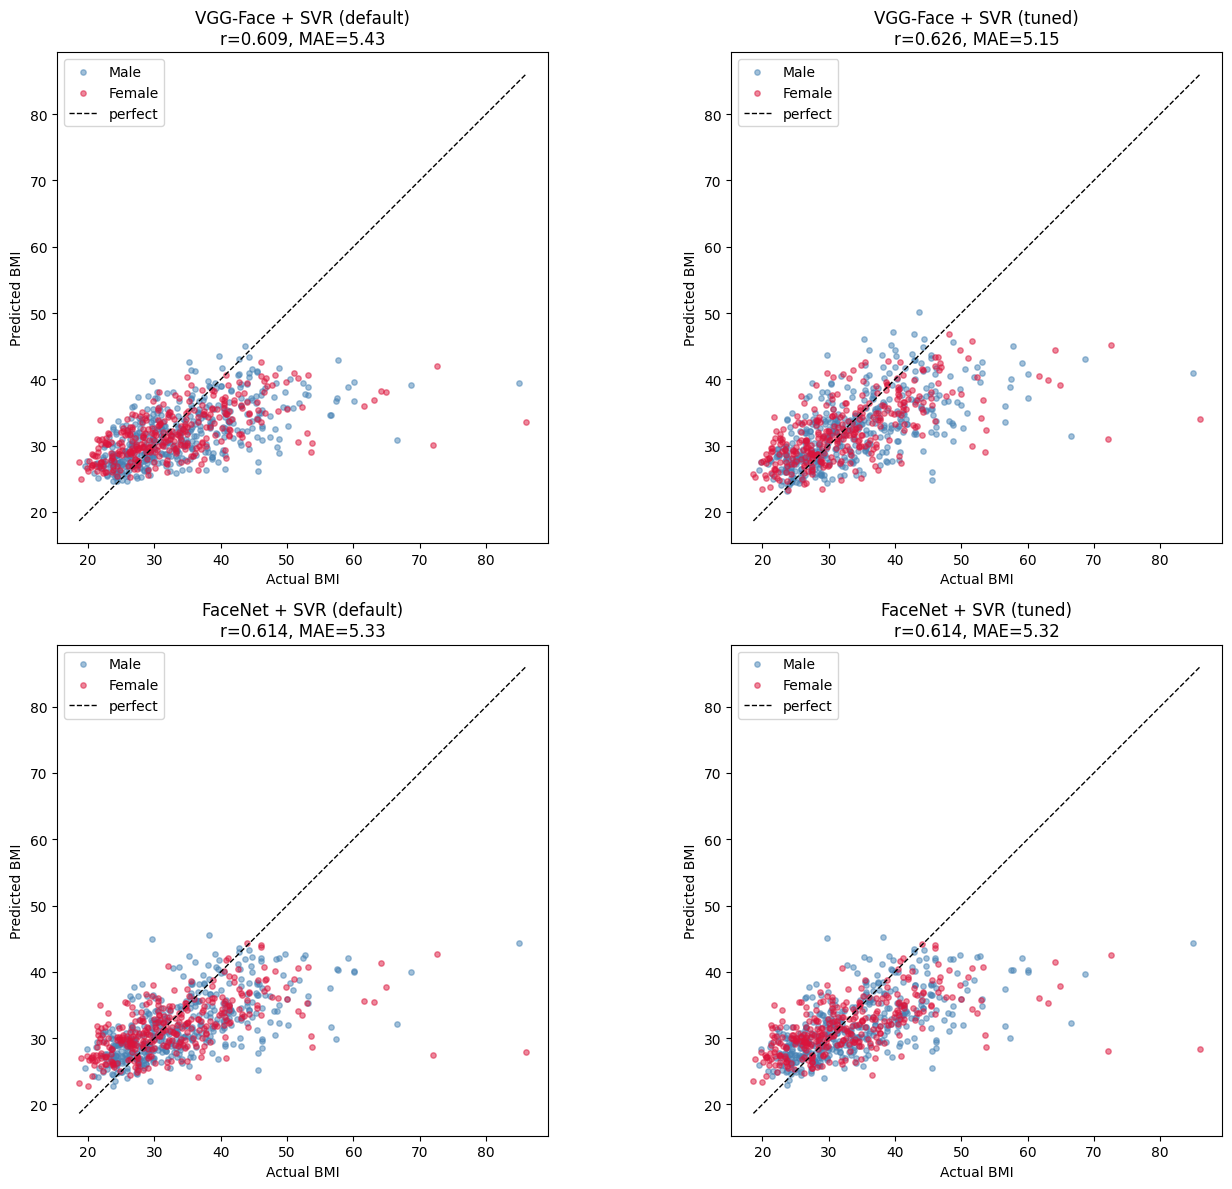

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

results_to_plot = [
    (vgg_default_results, axes[0, 0]),
    (vgg_tuned_results,   axes[0, 1]),
    (fn_default_results,  axes[1, 0]),
    (fn_tuned_results,    axes[1, 1]),
]

for r, ax in results_to_plot:
    male_mask = r['gender'] == 'Male'
    ax.scatter(r['y_true'][male_mask], r['y_pred'][male_mask],
               alpha=0.5, s=15, color='steelblue', label='Male')
    ax.scatter(r['y_true'][~male_mask], r['y_pred'][~male_mask],
               alpha=0.5, s=15, color='crimson', label='Female')

    # 45-degree perfect-prediction line
    lims = [min(r['y_true'].min(), r['y_pred'].min()),
            max(r['y_true'].max(), r['y_pred'].max())]
    ax.plot(lims, lims, 'k--', lw=1, label='perfect')

    ax.set_xlabel('Actual BMI')
    ax.set_ylabel('Predicted BMI')
    ax.set_title(f"{r['label']}\nr={r['r_overall']:.3f}, MAE={r['mae']:.2f}")
    ax.legend(loc='upper left')
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

## Cell 8: Error distribution

Histogram of (predicted - actual). Tells us:

- Is the model biased high or low on average? (If centered above 0 = systematically overpredicting BMI)
- How wide are the errors? Is it usually within ±5 BMI units, or do we have wild misses?

This matters for the demo: showing a user a 95% confidence interval is more honest than a single point estimate.

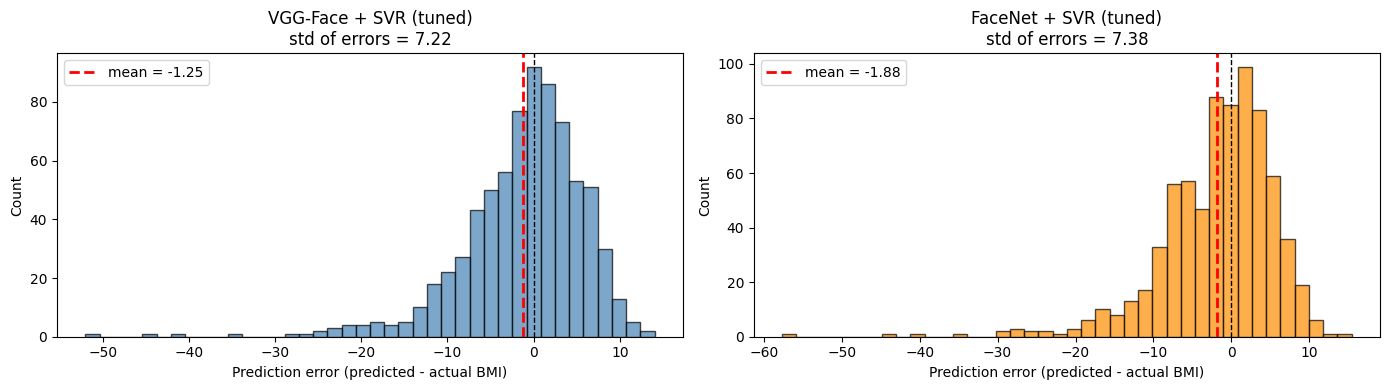

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for r, ax, color in [
    (vgg_tuned_results, axes[0], 'steelblue'),
    (fn_tuned_results,  axes[1], 'darkorange'),
]:
    errors = r['y_pred'] - r['y_true']
    ax.hist(errors, bins=40, color=color, alpha=0.7, edgecolor='black')
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.axvline(errors.mean(), color='red', linestyle='--', linewidth=2, label=f'mean = {errors.mean():.2f}')
    ax.set_xlabel('Prediction error (predicted - actual BMI)')
    ax.set_ylabel('Count')
    ax.set_title(f"{r['label']}\nstd of errors = {errors.std():.2f}")
    ax.legend()

plt.tight_layout()
plt.show()

## Cell 9: Save the winning model

Pick whichever model had the higher overall Pearson r. Save it to Drive so the demo (Phase 4) can load it without retraining.

**About `joblib`:** scikit-learn's recommended way to save fitted models. `joblib.dump` writes the model to a file, `joblib.load` reads it back as the exact same object. It handles numpy arrays inside the model efficiently (better than pickle for this use case).

In [11]:
import joblib

# Save BOTH tuned models (we may want to compare them in the write-up even if we only deploy one)
joblib.dump(vgg_grid.best_estimator_, f'{MODELS_DIR}/svr_vgg_tuned.joblib')
joblib.dump(fn_grid.best_estimator_,  f'{MODELS_DIR}/svr_facenet_tuned.joblib')

# Pick winner based on overall Pearson r
if vgg_tuned_results['r_overall'] >= fn_tuned_results['r_overall']:
    winner_label = 'VGG-Face + SVR (tuned)'
    winner_tag = 'VGG_Face'
    winner_r = vgg_tuned_results['r_overall']
else:
    winner_label = 'FaceNet + SVR (tuned)'
    winner_tag = 'Facenet512'
    winner_r = fn_tuned_results['r_overall']

print(f'\nBoth tuned models saved to: {MODELS_DIR}')
print(f'\nWinner: {winner_label} (r = {winner_r:.4f})')
print(f'Use feature extractor: {winner_tag}')
print(f'\nSave this info for Phase 4 demo!')


Both tuned models saved to: /content/drive/MyDrive/Colab Notebooks/uChicago/ML/ML Final/models

Winner: VGG-Face + SVR (tuned) (r = 0.6261)
Use feature extractor: VGG_Face

Save this info for Phase 4 demo!


## What you should see and what to tell me

Paste me back:
1. The full **Cell 6 comparison table** (the most important thing)
2. Which model won (Cell 9 output)
3. Any observations about the scatter plots in Cell 7

## Interpretation guide

**If tuned model overall r is 0.60-0.70** → solid replication, we have a working baseline
**If 0.55-0.60** → slightly under paper but still defensible (smaller dataset, weight conversion differences)
**If above 0.70** → unexpectedly good, double-check no test leakage (we should be safe but worth a sanity look)
**If below 0.50** → something's wrong, we'll debug

Don't be alarmed if female r is much lower than male r — it's lower in the paper too. Likely reasons: more variation in female facial features (makeup, hair styling, etc.) and the dataset has fewer female examples (1,557 vs 2,307 male in your data).

## Next: Phase 4

Once we have a winner, Phase 4 splits into two parallel tracks:
- **Track A:** Try to beat this baseline with more sophisticated approaches (different feature extractors, neural network head instead of SVR, ensembling)
- **Track B:** Build the Streamlit demo with webcam input using the current best model

We can do them in parallel because Track A is your 'science' work and Track B is your 'engineering' work — they don't block each other.